In [36]:
# imports
import numpy as np
import pandas as pd
from math import sqrt
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV, TimeSeriesSplit, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.exceptions import ConvergenceWarning
import warnings

In [27]:
## FINAL FEATURE SELECTION

feats = ['HRk', 'HAvAge', 'HW', 'HL', 'HOL', 'HPTS%', 'HSOW', 'HSRS', 'HSOS', 'HGF/G', 
         'HGA/G', 'HPP', 'HPPO', 'HPPA', 'HPPOA', 'HSH', 'HSHA', 'HPIM/G', 'HS%', 'HSV%', 
         'HSO', 'HCAN', 'VRk', 'VAvAge', 'VL', 'VPP', 'VPPO', 'VSH', 'VPIM/G', 'VoPIM/G', 
         'VS%', 'VSV%', 'TDAY', 'FDAY', 'SDAY', 'SuDAY', 'DIV', 'CAP', 'LCAP', 'HSTAR']

In [28]:
# load data
df_att_all = pd.read_csv('attendance data with features.csv')

# only feature selection
df_att = df_att_all[['A', 'PA', 'LA'] + feats]

# Set random seed
rand_seed = 34

In [29]:
# Define models
models = {
    "OLS": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "ElasticNet": ElasticNet(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(),
    "Gradient Boosting": GradientBoostingRegressor()
}

# regularization parameters
# optimal values for l1_alpha found in Data Feature Selection
lasso_A = 3.59
lasso_LA = 0.000129
lasso_PA = 0.000279

ridge_A = 0.5
ridge_LA = 0.1
ridge_PA = 0.1

# Define model parameters for each dependent variable type
model_params = {
    "A": {
        "OLS": {},
        "Lasso": {'alpha': lasso_A},
        "Ridge": {'alpha': ridge_A},
        "ElasticNet": {
            'alpha': (lasso_A + ridge_A) * 0.25,  # Sum of Lasso and Ridge alphas, multiplied by 0.25 to avoid over-regularization
            'l1_ratio': lasso_A / (lasso_A + ridge_A)  # Ratio based on Lasso strength
        },
        "Decision Tree": {'max_depth': 15, 'random_state': rand_seed},
        "Random Forest": {'n_estimators': 100, 'random_state': rand_seed},
        "Gradient Boosting": {'n_estimators': 100, 'learning_rate': 0.1, 'random_state': rand_seed}
    },
    "LA": {
        "OLS": {},
        "Lasso": {'alpha': lasso_LA},
        "Ridge": {'alpha': ridge_LA},
        "ElasticNet": {
            'alpha': (lasso_LA + ridge_LA) * 0.25,
            'l1_ratio': lasso_LA / (lasso_LA + ridge_LA)
        },
        "Decision Tree": {'max_depth': 15, 'random_state': rand_seed},
        "Random Forest": {'n_estimators': 100, 'random_state': rand_seed},
        "Gradient Boosting": {'n_estimators': 200, 'learning_rate': 0.1, 'random_state': rand_seed}
    },
    "PA": {
        "OLS": {},
        "Lasso": {'alpha': lasso_PA},
        "Ridge": {'alpha': ridge_PA},
        "ElasticNet": {
            'alpha': (lasso_PA + ridge_PA) * 0.25,
            'l1_ratio': lasso_PA / (lasso_PA + ridge_PA)
        },
        "Decision Tree": {'max_depth': 15, 'random_state': rand_seed},
        "Random Forest": {'n_estimators': 100, 'random_state': rand_seed},
        "Gradient Boosting": {'n_estimators': 100, 'learning_rate': 0.1, 'random_state': rand_seed}
    }
}

In [30]:
# Function to compute evaluation metrics with dependent variable transformation
def compute_stats(dep, X_train, X_test, y_train, y_train_pred, y_test, y_test_pred):
    if dep == 'A':
        y_train_true, y_train_pred = y_train, y_train_pred
        y_test_true, y_test_pred = y_test, y_test_pred

    elif dep == 'LA':
        y_train_true, y_train_pred = np.exp(y_train), np.exp(y_train_pred)
        y_test_true, y_test_pred = np.exp(y_test), np.exp(y_test_pred)

    elif dep == 'PA':
        y_train_true, y_train_pred = y_train * X_train['CAP'], y_train_pred * X_train['CAP']
        y_test_true, y_test_pred = y_test * X_test['CAP'], y_test_pred * X_test['CAP']

    return {
        "RMSE Train": sqrt(mean_squared_error(y_train_true, y_train_pred)),
        "MAE Train": mean_absolute_error(y_train_true, y_train_pred),
        "R² Train": r2_score(y_train_true, y_train_pred),
        "RMSE Test": sqrt(mean_squared_error(y_test_true, y_test_pred)),
        "MAE Test": mean_absolute_error(y_test_true, y_test_pred),
        "R² Test": r2_score(y_test_true, y_test_pred)
    }

In [31]:
def run_model(model, model_name, X_train, X_test, y_train, y_test, dep, model_params):
    # Select the correct parameters for the given dep
    params = model_params[dep].get(model_name)

    # If the model is 'Lasso', 'ElasticNet', or 'Ridge', scale the features
    if model_name in ["Lasso", "ElasticNet"]:
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        model.set_params(**params)  # Set the parameters for the model
        model.fit(X_train_scaled, y_train)
        y_train_pred = model.predict(X_train_scaled)
        y_test_pred = model.predict(X_test_scaled)
    else:
        model.set_params(**params)  # Set the parameters for the model
        model.fit(X_train, y_train)
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)
    
    return {"Model": model_name, **compute_stats(dep, X_train, X_test, y_train, y_train_pred, y_test, y_test_pred)}

In [32]:
def plot_predict(models, X_train, X_test, y_train, y_test, dep, model_params):    
    # Set plot style
    sns.set_style("whitegrid")
    
    # Plot actual vs. predicted for each model
    fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))
    axes = axes.flatten()
    
    for i, (name, model) in enumerate(models.items()):
        # Select the correct parameters for the given dep
        params = model_params[dep].get(name)
        
        # Fit and predict for the model
        if name in ["Lasso", "ElasticNet"]:
            # Scale features for Lasso and ElasticNet
            scaler = StandardScaler()
            X_train_scaled = scaler.fit_transform(X_train)
            X_test_scaled = scaler.transform(X_test)
            model.set_params(**params)  # Set the parameters
            model.fit(X_train_scaled, y_train)
            y_train_pred = model.predict(X_train_scaled)
            y_test_pred = model.predict(X_test_scaled)
        else:
            model.set_params(**params)  # Set the parameters
            model.fit(X_train, y_train)
            y_train_pred = model.predict(X_train)
            y_test_pred = model.predict(X_test)

        # Apply dependent variable transformations and plot accordingly
        if dep == 'LA':
            y_test_la = np.exp(y_test)
            y_test_pred_la = np.exp(y_test_pred)

            ax = axes[i]
            ax.scatter(y_test_la, y_test_pred_la, alpha=0.5, color='red', marker='.')
            ax.plot([min(y_test_la), max(y_test_la)], [min(y_test_la), max(y_test_la)], color='black', linestyle='--')
            ax.set_title(f"{name}: Actual vs. Predicted (Log-Transformed)")
            ax.set_xlabel("Actual Attendance (Log)")
            ax.set_ylabel("Predicted Attendance (Log)")

        elif dep == 'PA':
            y_test_pa = y_test * X_test['CAP']
            y_test_pred_pa = y_test_pred * X_test['CAP']

            ax = axes[i]
            ax.scatter(y_test_pa, y_test_pred_pa, alpha=0.5, color='red', marker='.')
            ax.plot([min(y_test_pa), max(y_test_pa)], [min(y_test_pa), max(y_test_pa)], color='black', linestyle='--')
            ax.set_title(f"{name}: Actual vs. Predicted (Capacity Adjusted)")
            ax.set_xlabel("Actual Attendance (Capacity Adjusted)")
            ax.set_ylabel("Predicted Attendance (Capacity Adjusted)")

        else:
            ax = axes[i]
            ax.scatter(y_test, y_test_pred, alpha=0.5, color='red', marker='.')
            ax.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='black', linestyle='--')
            ax.set_title(f"{name}: Actual vs. Predicted (Original)")
            ax.set_xlabel("Actual Attendance")
            ax.set_ylabel("Predicted Attendance")

    # Hide unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

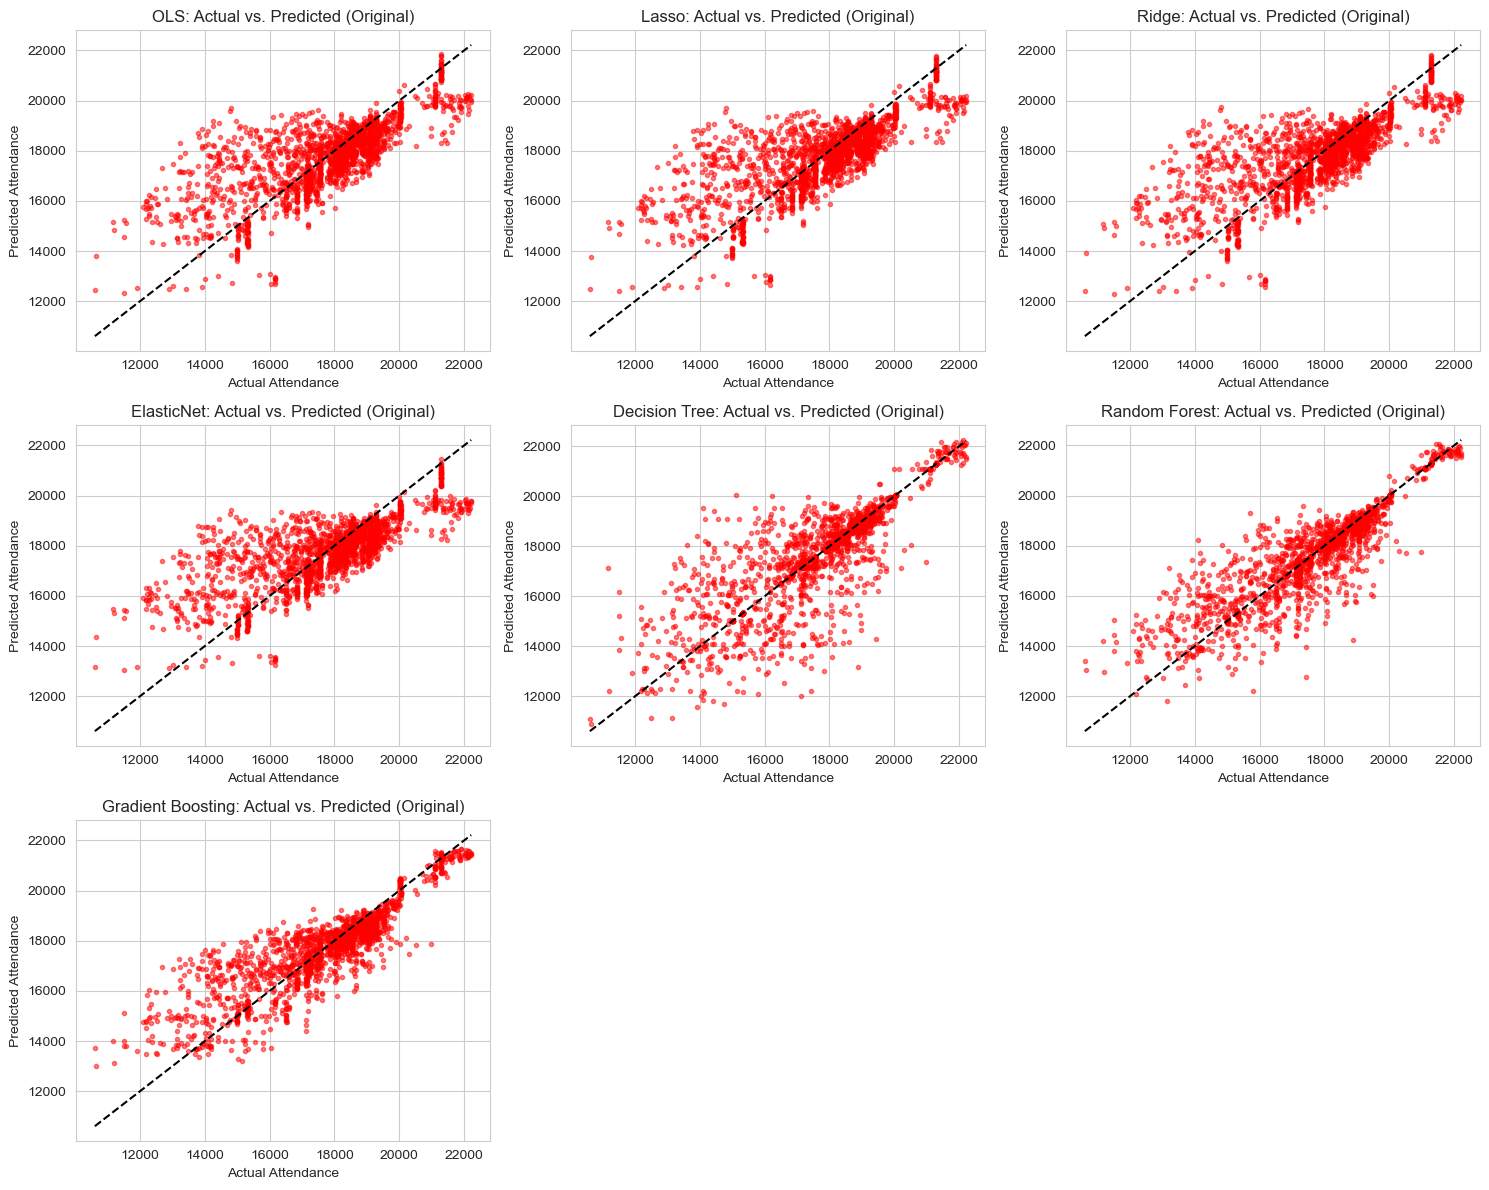

,Model,RMSE Train,MAE Train,R² Train,RMSE Test,MAE Test,R² Test
0,OLS,1285.551989,907.186515,0.543396,1293.828516,914.928554,0.559906
1,Lasso,1287.459398,908.302420,0.542040,1296.844561,918.771413,0.557852
2,Ridge,1287.395946,908.773450,0.542085,1295.846252,917.623871,0.558532
3,ElasticNet,1307.617449,923.327856,0.527587,1317.816353,938.558947,0.543436
4,Decision Tree,306.460916,128.260299,0.974052,1167.847034,653.753666,0.641438
5,Random Forest,351.254667,202.499475,0.965912,904.069457,534.980362,0.785120
6,Gradient Boosting,901.443844,615.432508,0.775489,959.380970,655.101519,0.758023


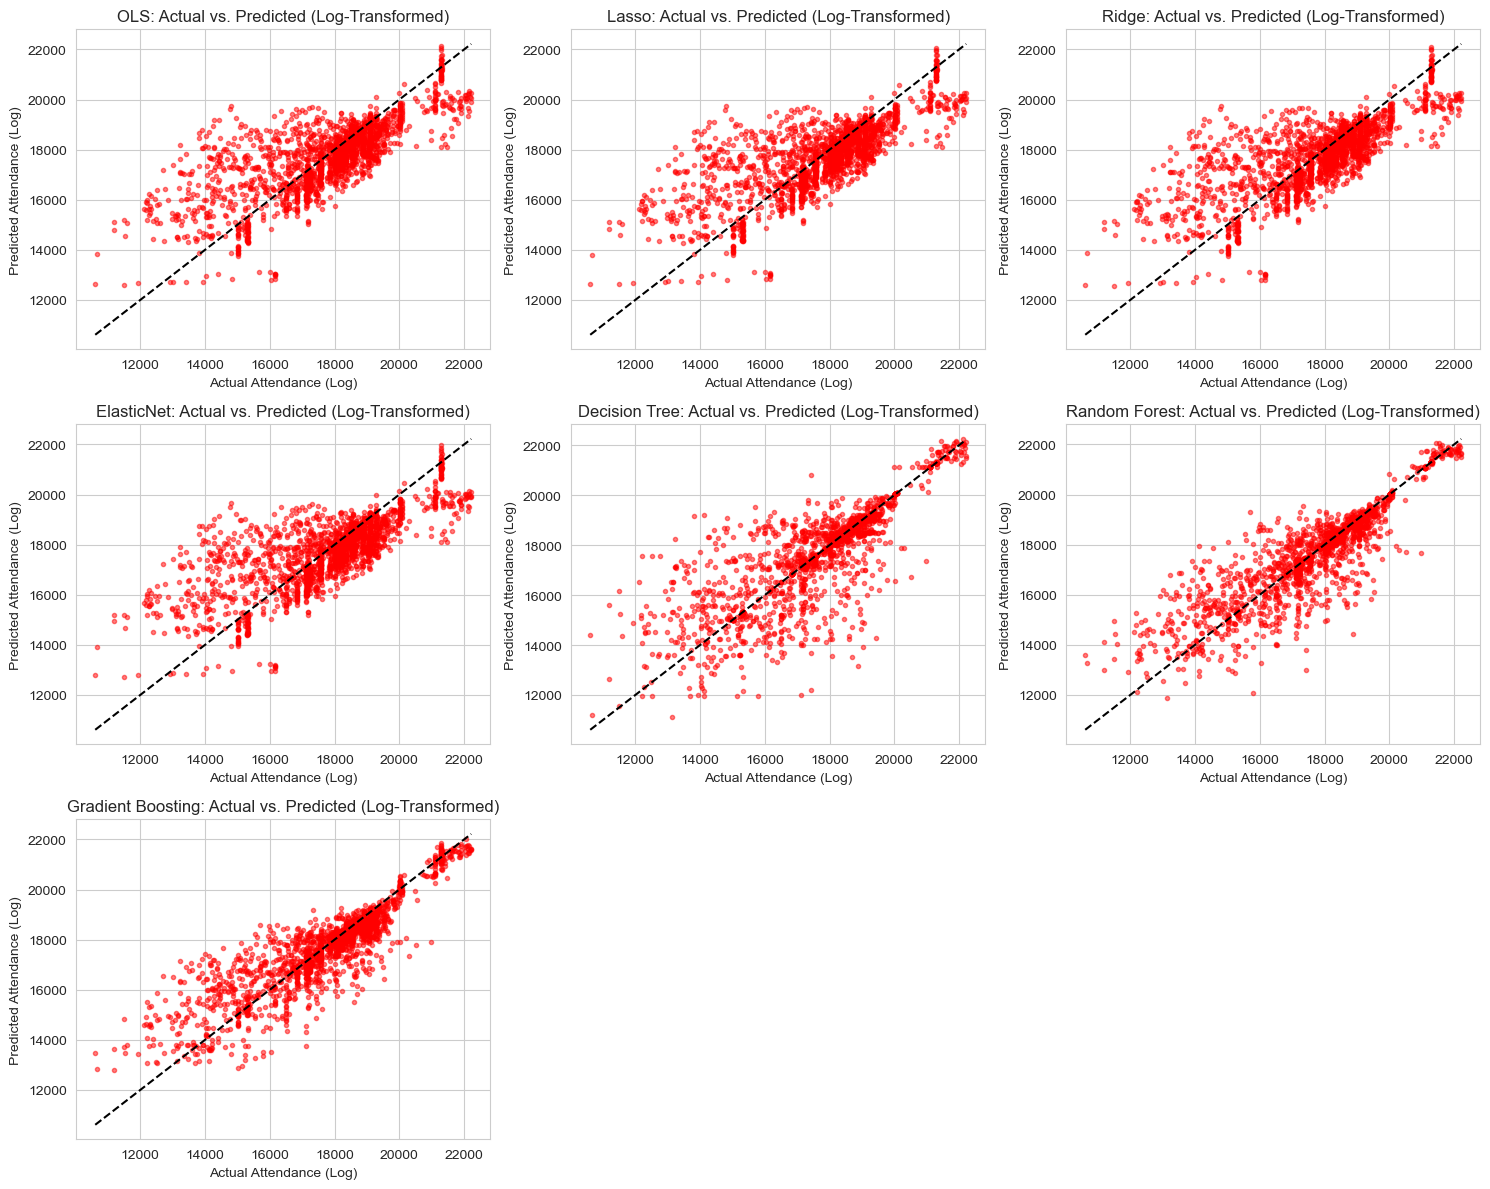

,Model,RMSE Train,MAE Train,R² Train,RMSE Test,MAE Test,R² Test
0,OLS,1289.194096,929.788056,0.540805,1294.629274,935.289729,0.559361
1,Lasso,1289.908933,930.728302,0.540295,1296.093903,937.762859,0.558364
2,Ridge,1289.150912,929.547399,0.540835,1294.677613,935.750352,0.559328
3,ElasticNet,1293.345025,932.926710,0.537843,1299.885754,941.412252,0.555776
4,Decision Tree,403.569036,178.723437,0.955002,1164.367445,654.505066,0.643572
5,Random Forest,351.919659,203.081961,0.965783,897.280884,530.441257,0.788335
6,Gradient Boosting,811.705760,551.568811,0.817964,906.454155,608.864618,0.783985


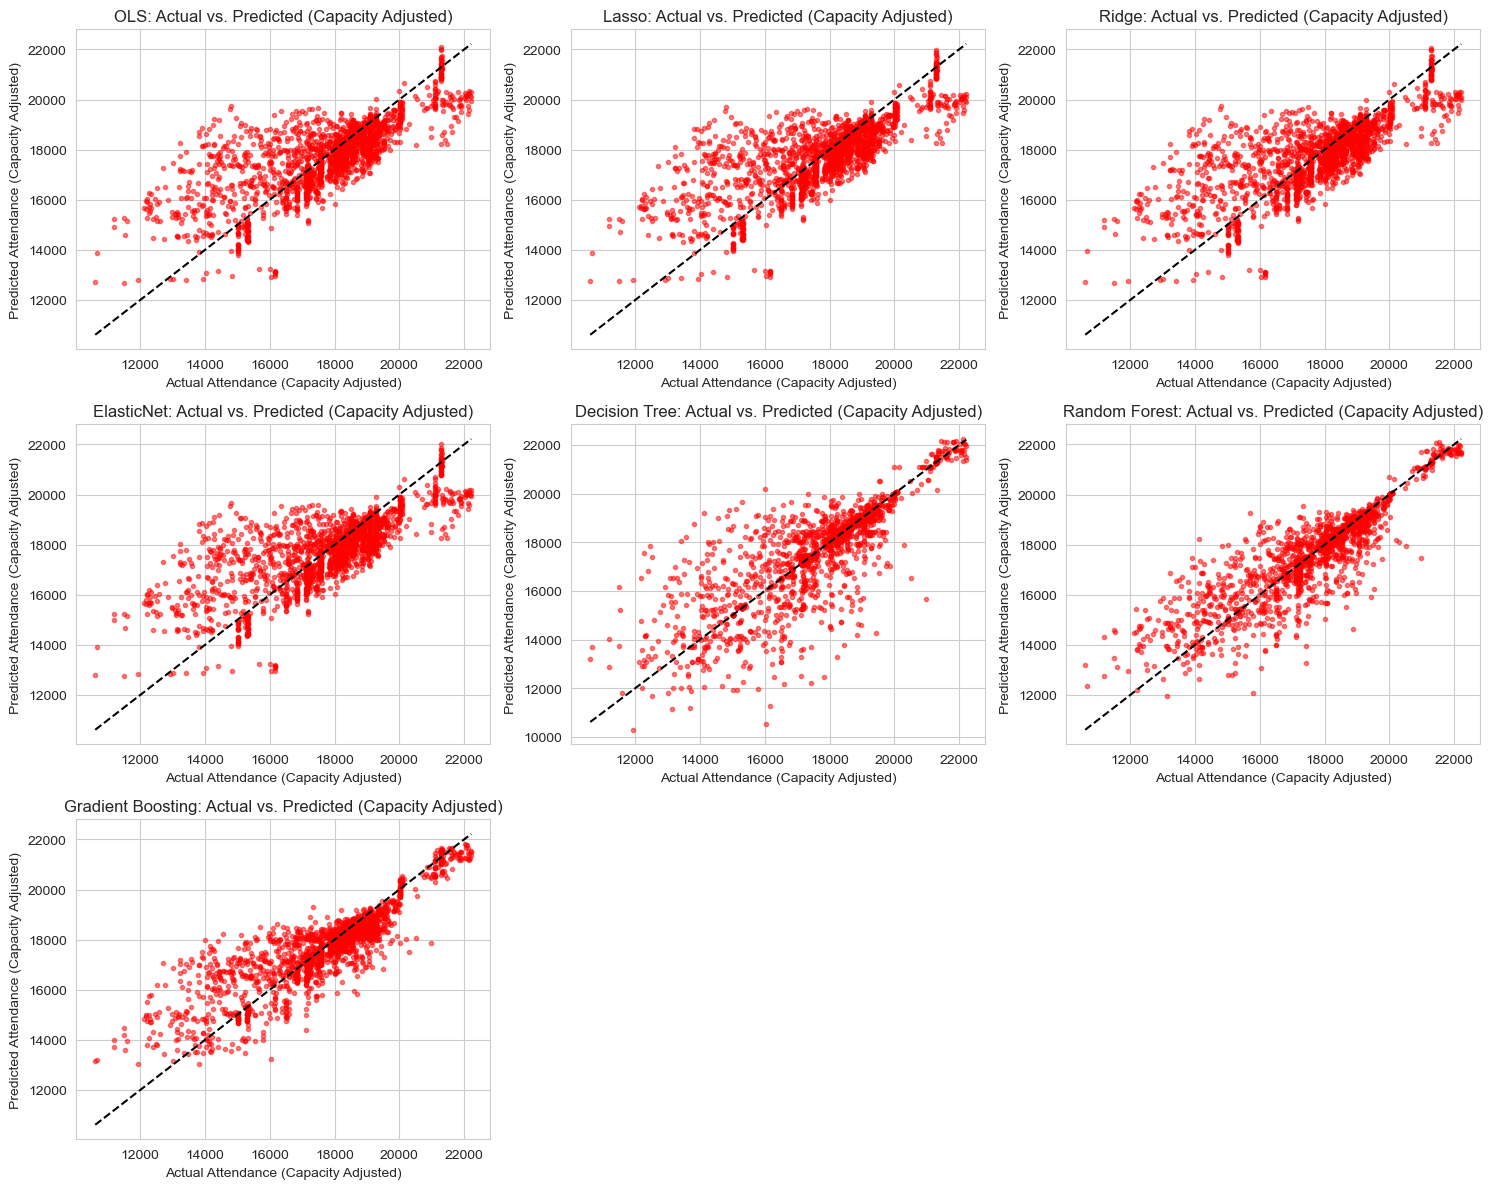

,Model,RMSE Train,MAE Train,R² Train,RMSE Test,MAE Test,R² Test
0,OLS,1286.021422,909.499983,0.543062,1293.829985,916.612990,0.559905
1,Lasso,1289.459059,911.038403,0.540616,1299.183202,921.801889,0.556256
2,Ridge,1286.050347,909.224945,0.543041,1293.987307,916.885836,0.559798
3,ElasticNet,1290.546049,912.158496,0.539841,1300.026664,922.737656,0.555679
4,Decision Tree,372.448851,157.461786,0.961674,1150.963196,642.885544,0.651731
5,Random Forest,352.435487,203.724884,0.965682,892.294278,531.313539,0.790681
6,Gradient Boosting,911.306200,620.824775,0.770549,968.788636,660.501831,0.753254


In [33]:
# Dependent variable
deps = ['A', 'LA', 'PA']

for dep in deps:
    if dep == 'A' or dep == 'PA':
        X = df_att.drop(columns=['A', 'LA', 'PA', 'LCAP'])
    else:
        X = df_att.drop(columns=['A', 'LA', 'PA', 'CAP'])

    y = df_att[dep]
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=rand_seed)

    results = [run_model(model, name, X_train, X_test, y_train, y_test, dep, model_params) for name, model in models.items()]
    df_results = pd.DataFrame(results)

    plot_predict(models, X_train, X_test, y_train, y_test, dep, model_params)

    display(df_results)

In [37]:
def kfold_cv(model, model_name, X, y, dep, model_params, n_splits=5):
    kf = KFold(n_splits=n_splits)#, shuffle=True, random_state=rand_seed)
    results = []

    # Set model parameters if available
    params = model_params.get(dep, {}).get(model_name, {})
    
    for train_index, val_index in kf.split(X):
        X_train, X_val = X.iloc[train_index], X.iloc[val_index]
        y_train, y_val = y.iloc[train_index], y.iloc[val_index]

        # Extract the 'CAP' column before scaling if it's present
        cap_train = X_train['CAP'] if 'CAP' in X_train.columns else None
        cap_val = X_val['CAP'] if 'CAP' in X_val.columns else None

        # Scaling for Lasso and ElasticNet
        if model_name in ["Lasso", "ElasticNet"]:
            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_val = scaler.transform(X_val)

        # Initialize model with the parameters from model_params (if any)
        if params:
            model.set_params(**params)

        # Fit the model
        # model.fit(X_train, y_train)

        # Fit the model with warning capture
        with warnings.catch_warnings(record=True) as w:
            warnings.simplefilter("always", ConvergenceWarning)
            model.fit(X_train, y_train)
            
            # Print convergence warnings with context
            for warning in w:
                if issubclass(warning.category, ConvergenceWarning):
                    print(f"⚠️ Convergence warning during {model_name} on {dep}: {warning.message}")
        
        y_train_pred = model.predict(X_train)
        y_val_pred = model.predict(X_val)

        # Apply dependent variable transformation based on `dep`
        if dep == 'A':
            y_train_true, y_train_pred = y_train, y_train_pred
            y_val_true, y_val_pred = y_val, y_val_pred
        elif dep == 'LA':
            y_train_true, y_train_pred = np.exp(y_train), np.exp(y_train_pred)
            y_val_true, y_val_pred = np.exp(y_val), np.exp(y_val_pred)
        elif dep == 'PA':
            if cap_train is not None:
                y_train_true, y_train_pred = y_train * cap_train, y_train_pred * cap_train
                y_val_true, y_val_pred = y_val * cap_val, y_val_pred * cap_val
            else:
                raise ValueError("CAP column is missing in the dataset.")

        # Compute evaluation metrics
        metrics = {
            "RMSE Train": sqrt(mean_squared_error(y_train_true, y_train_pred)),
            "MAE Train": mean_absolute_error(y_train_true, y_train_pred),
            "R² Train": r2_score(y_train_true, y_train_pred),
            "RMSE Test": sqrt(mean_squared_error(y_val_true, y_val_pred)),
            "MAE Test": mean_absolute_error(y_val_true, y_val_pred),
            "R² Test": r2_score(y_val_true, y_val_pred)
        }

        results.append(metrics)

    # Convert results to DataFrame and compute average scores
    results_df = pd.DataFrame(results)
    avg_scores = results_df.mean().to_dict()
    avg_scores["Model"] = model_name  # Add model name for reference

    return avg_scores

In [38]:
# Dependent variable
deps = ['A', 'LA', 'PA']

for dep in deps:
    # Prepare features and target variable
    if dep == 'A' or dep == 'PA':
        X = df_att.drop(columns=['A', 'LA', 'PA', 'LCAP'])
    else:
        X = df_att.drop(columns=['A', 'LA', 'PA', 'CAP'])
    
    y = df_att[dep]
    
    # Run all models with kfold CV
    cv_results = [kfold_cv(model, name, X, y, dep, model_params) for name, model in models.items()]
    
    # Convert results to a DataFrame
    df_cv_results = pd.DataFrame(cv_results)
    
    # display
    display(df_cv_results)

,RMSE Train,MAE Train,R² Train,RMSE Test,MAE Test,R² Test,Model
0,1274.922432,905.617846,0.554730,1430.206937,1047.226137,0.424200,OLS
1,1277.473866,907.041036,0.552938,1416.313352,1038.050571,0.434926,Lasso
2,1277.283760,907.073078,0.553105,1420.833112,1039.487645,0.432503,Ridge
3,1299.011459,922.480807,0.537739,1410.774999,1037.914185,0.439524,ElasticNet
4,356.920007,153.147222,0.964820,1553.125208,968.514476,0.292093,Decision Tree
5,358.948700,204.423967,0.964665,1160.481045,772.434445,0.610147,Random Forest
6,894.090012,607.560485,0.780709,1203.709225,866.225773,0.586132,Gradient Boosting


,RMSE Train,MAE Train,R² Train,RMSE Test,MAE Test,R² Test,Model
0,1278.967006,927.610193,0.551888,1438.766106,1071.243055,0.416262,OLS
1,1280.120555,928.671172,0.551069,1425.028066,1062.393845,0.426885,Lasso
2,1278.963716,927.379042,0.551891,1433.715635,1067.166617,0.420849,Ridge
3,1284.046512,931.354614,0.548309,1422.133145,1063.225134,0.429625,ElasticNet
4,392.327402,176.065579,0.957802,1530.409366,965.656600,0.316508,Decision Tree
5,358.714962,204.652570,0.964713,1205.825724,795.781019,0.574158,Random Forest
6,806.976827,546.825858,0.821320,1223.916233,884.352984,0.568611,Gradient Boosting


,RMSE Train,MAE Train,R² Train,RMSE Test,MAE Test,R² Test,Model
0,1275.609963,907.713866,0.554232,1425.554689,1044.480384,0.427486,OLS
1,1279.789834,910.036705,0.551302,1408.932287,1033.963218,0.440245,Lasso
2,1275.723662,907.385181,0.554156,1420.881293,1040.501830,0.431684,Ridge
3,1281.112937,910.839232,0.550366,1408.322892,1035.496505,0.440895,ElasticNet
4,455.176368,204.550429,0.942516,1627.999555,1043.832743,0.226257,Decision Tree
5,358.158173,204.105765,0.964823,1253.396853,850.872787,0.544368,Random Forest
6,907.200612,614.724277,0.774313,1214.644268,876.517020,0.579368,Gradient Boosting


In [11]:
# Define Random Forest hyperparameter grid
rf_param_grid = {
    'n_estimators': [50, 100, 200, 500, 750],
    'max_depth': [None, 10, 20, 30, 50],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [5, 10, 20, 50, 100],
    'max_features': ['sqrt', 'log2', None]
}

# Define Gradient Boosting hyperparameter grid
gb_param_grid = {
    'n_estimators': [50, 100, 200, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 5, 10]
}

# Initialize models
rf = RandomForestRegressor(random_state=rand_seed)
gb = GradientBoostingRegressor(random_state=rand_seed)

# Initialize RandomizedSearchCV with TimeSeriesSplit
rf_random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=rf_param_grid,
    n_iter=20,  # Number of different combinations to try
    cv=5,
    scoring='neg_root_mean_squared_error',
    random_state=rand_seed,
    n_jobs=-1
)

gb_random_search = RandomizedSearchCV(
    estimator=gb,
    param_distributions=gb_param_grid,
    n_iter=20,
    cv=5,
    scoring='neg_root_mean_squared_error',
    random_state=rand_seed,
    n_jobs=-1
)

In [13]:
# Initialize an empty dictionary to store the best parameters
best_params = {}

for dep in ['A', 'LA', 'PA']:
    # Prepare features and target variable
    if dep in ['A', 'PA']:
        X = df_att.drop(columns=['A', 'LA', 'PA', 'LCAP'])
    else:
        X = df_att.drop(columns=['A', 'LA', 'PA', 'CAP'])
    
    y = df_att[dep]
    
    # Fit Random Forest model
    rf_random_search.fit(X, y)
    best_params[f"RandomForest_{dep}"] = rf_random_search.best_params_

    print(f'done RF for {dep}')
    
    # Fit Gradient Boosting model
    gb_random_search.fit(X, y)
    best_params[f"GradientBoosting_{dep}"] = gb_random_search.best_params_

    print(f'done XGBoost for {dep}')

# Create a DataFrame from the best_params dictionary
best_params_df = pd.DataFrame.from_dict(best_params, orient='index')

# Replace NaN values with '-' for better readability
best_params_df = best_params_df.fillna('-')

# Display the DataFrame
print("\nBest Parameters DataFrame:")
display(best_params_df)

done RF for A
done XGBoost for A
done RF for LA
done XGBoost for LA
done RF for PA
done XGBoost for PA

Best Parameters DataFrame:


,n_estimators,min_samples_split,min_samples_leaf,max_features,max_depth,learning_rate
RandomForest_A,200,20,5,None,NaN,NaN
GradientBoosting_A,100,5,5,NaN,5.0,0.1
RandomForest_LA,200,20,5,None,NaN,NaN
GradientBoosting_LA,100,5,5,NaN,5.0,0.1
RandomForest_PA,50,5,10,log2,NaN,NaN
GradientBoosting_PA,100,5,5,NaN,5.0,0.1


Results for Random Forest - Dependent Variable: A
Train RMSE: 670.5061, MAE: 399.4408, R²: 0.8773
Test  RMSE: 864.3872, MAE: 508.1619, R²: 0.7936
--------------------------------------------------


/var/folders/z6/55zl8z_1365b2p_8lkhq6tzr0000gn/T/ipykernel_16704/3484930500.py:55: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_results = pd.concat([df_results, pd.DataFrame([{


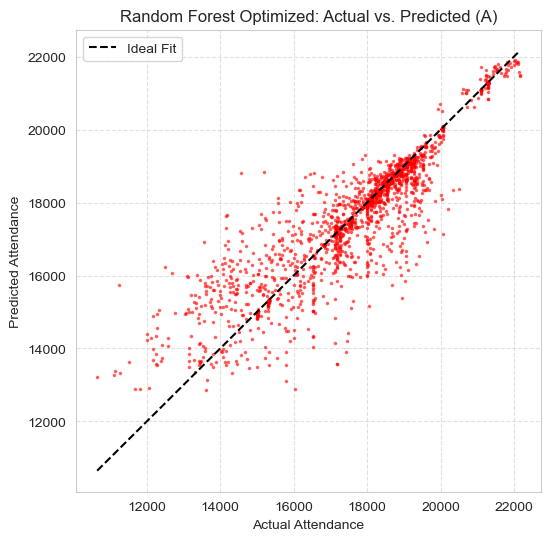

Results for Gradient Boosting - Dependent Variable: A
Train RMSE: 714.5158, MAE: 465.8743, R²: 0.8607
Test  RMSE: 867.1133, MAE: 548.0810, R²: 0.7923
--------------------------------------------------


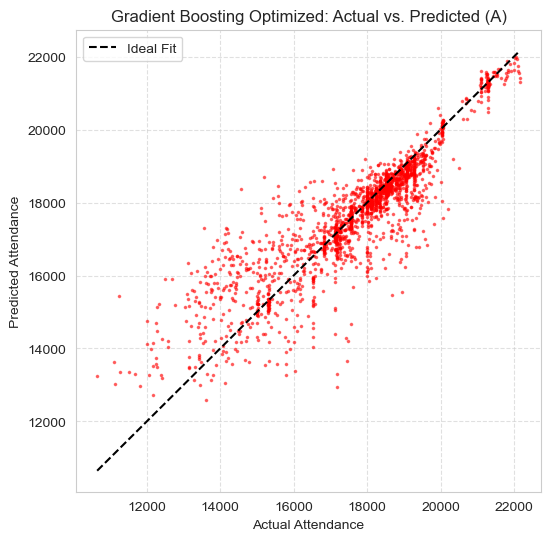

Results for Random Forest - Dependent Variable: LA
Train RMSE: 675.3557, MAE: 402.8330, R²: 0.8756
Test  RMSE: 870.2220, MAE: 510.8523, R²: 0.7908
--------------------------------------------------


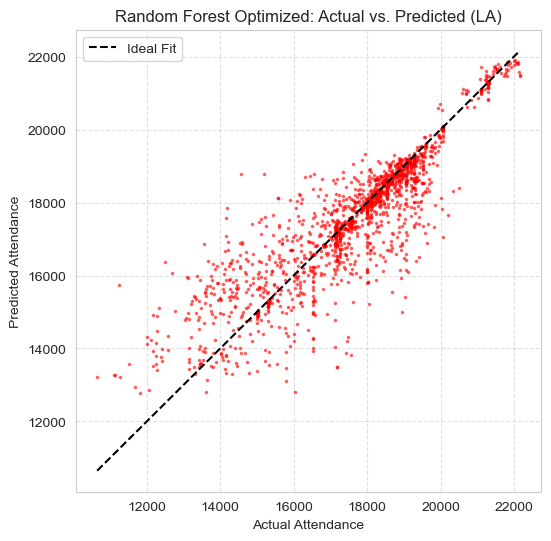

Results for Gradient Boosting - Dependent Variable: LA
Train RMSE: 710.1502, MAE: 474.0582, R²: 0.8624
Test  RMSE: 872.4708, MAE: 561.0842, R²: 0.7897
--------------------------------------------------


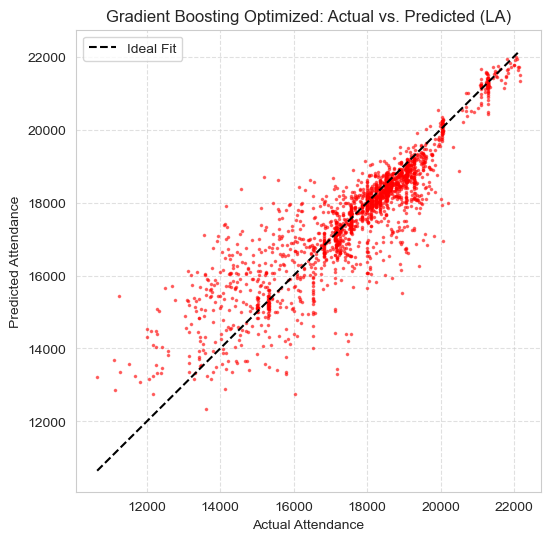

Results for Random Forest - Dependent Variable: PA
Train RMSE: 796.2192, MAE: 481.8226, R²: 0.8270
Test  RMSE: 884.4350, MAE: 524.1577, R²: 0.7839
--------------------------------------------------


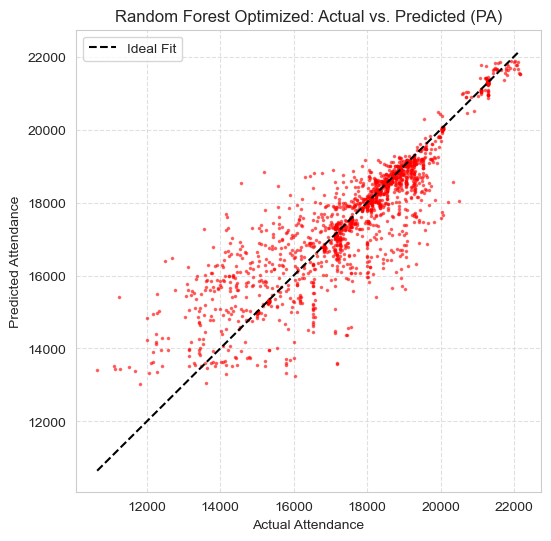

Results for Gradient Boosting - Dependent Variable: PA
Train RMSE: 727.3012, MAE: 477.8148, R²: 0.8557
Test  RMSE: 879.4664, MAE: 559.3576, R²: 0.7863
--------------------------------------------------


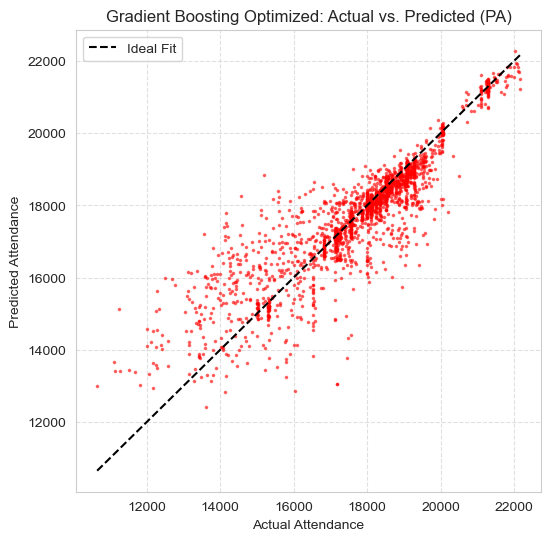

,Dep,Model,RMSE Train,MAE Train,R² Train,RMSE Test,MAE Test,R² Test
0,A,Random Forest,670.506081,399.440768,0.877343,864.387214,508.161909,0.793606
1,A,Gradient Boosting,714.515801,465.874317,0.860713,867.113321,548.081015,0.792302
2,LA,Random Forest,675.355700,402.832961,0.875562,870.222013,510.852295,0.790810
3,LA,Gradient Boosting,710.150244,474.058246,0.862409,872.470849,561.084243,0.789728
4,PA,Random Forest,796.219202,481.822594,0.827037,884.434980,524.157728,0.783921
5,PA,Gradient Boosting,727.301247,477.814842,0.855683,879.466430,559.357570,0.786342


In [14]:
# column names
columns = ["Dep", "Model", "RMSE Train", "MAE Train", "R² Train", "RMSE Test", "MAE Test", "R² Test"]

# initialize results list
results_list = []

# Loop through dependent variables and apply the best model for each
for dep in ['A', 'LA', 'PA']:
    # Prepare features and target variable
    if dep in ['A', 'PA']:
        X = df_att.drop(columns=['A', 'LA', 'PA', 'LCAP'])
    else:  # For 'LA'
        X = df_att.drop(columns=['A', 'LA', 'PA', 'CAP'])
    
    y = df_att[dep]
    
    # Split into train and test sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Select model type based on dependent variable
    rf_params = best_params[f"RandomForest_{dep}"]
    gb_params = best_params[f"GradientBoosting_{dep}"]

    # Train and evaluate both models
    for model_name, model_params, model_class in [
        ("Random Forest", rf_params, RandomForestRegressor),
        ("Gradient Boosting", gb_params, GradientBoostingRegressor)
    ]:
        # Instantiate the model with optimized hyperparameters
        model = model_class(random_state=rand_seed, **model_params)

        # Fit the model
        model.fit(X_train, y_train)
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        # **Adjust predictions based on dependent variable transformation**
        if dep == 'LA':  # Log Attendance was used → Apply exp()
            y_train_true, y_train_pred = np.exp(y_train), np.exp(y_train_pred)
            y_test_true, y_test_pred = np.exp(y_test), np.exp(y_test_pred)
        elif dep == 'PA':  # Percentage Attendance → Multiply by CAP
            y_train_true, y_train_pred = y_train * X_train['CAP'], y_train_pred * X_train['CAP']
            y_test_true, y_test_pred = y_test * X_test['CAP'], y_test_pred * X_test['CAP']
        else:  # 'A' (Raw Attendance) → No adjustment needed
            y_train_true, y_train_pred = y_train, y_train_pred
            y_test_true, y_test_pred = y_test, y_test_pred

        # Compute evaluation metrics
        rmse_train = np.sqrt(mean_squared_error(y_train_true, y_train_pred))
        mae_train = mean_absolute_error(y_train_true, y_train_pred)
        r2_train = r2_score(y_train_true, y_train_pred)

        rmse_test = np.sqrt(mean_squared_error(y_test_true, y_test_pred))
        mae_test = mean_absolute_error(y_test_true, y_test_pred)
        r2_test = r2_score(y_test_true, y_test_pred)

        # Store results in a list
        results_list.append({
            "Dep": dep,
            "Model": model_name,
            "RMSE Train": rmse_train,
            "MAE Train": mae_train,
            "R² Train": r2_train,
            "RMSE Test": rmse_test,
            "MAE Test": mae_test,
            "R² Test": r2_test
        })

        print(f"Results for {model_name} - Dependent Variable: {dep}")
        print(f"Train RMSE: {rmse_train:.4f}, MAE: {mae_train:.4f}, R²: {r2_train:.4f}")
        print(f"Test  RMSE: {rmse_test:.4f}, MAE: {mae_test:.4f}, R²: {r2_test:.4f}")
        print("-" * 50)

        # Scatter plot for actual vs predicted values
        fig, ax = plt.subplots(figsize=(6, 6))  # Define figure size
        ax.scatter(y_test_true, y_test_pred, alpha=0.5, color='red', marker='.', s=10)
        ax.plot([min(y_test_true), max(y_test_true)], [min(y_test_true), max(y_test_true)], 
                color='black', linestyle='--', label="Ideal Fit")  # Ideal fit line
        ax.set_title(f"{model_name} Optimized: Actual vs. Predicted ({dep})")
        ax.set_xlabel("Actual Attendance")
        ax.set_ylabel("Predicted Attendance")
        ax.grid(True, linestyle='--', alpha=0.6)
        ax.legend()
        
        plt.show()

# Convert list to DataFrame
df_results = pd.DataFrame(results_list)[columns]

# Display results table
df_results

In [15]:
### TIME SERIES CROSS VALIDATION

def time_series_cv(model, model_name, X, y, dep, model_params, n_splits=5):
    tscv = TimeSeriesSplit(n_splits=n_splits)
    results = []

    # Set model parameters if available
    params = model_params.get(dep, {}).get(model_name, {})
    
    for train_index, val_index in tscv.split(X):
        X_train, X_val = X.iloc[train_index], X.iloc[val_index]
        y_train, y_val = y.iloc[train_index], y.iloc[val_index]

        # Extract the 'CAP' column before scaling if it's present
        cap_train = X_train['CAP'] if 'CAP' in X_train.columns else None
        cap_val = X_val['CAP'] if 'CAP' in X_val.columns else None

        # Scaling for Lasso and ElasticNet
        if model_name in ["Lasso", "ElasticNet"]:
            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_val = scaler.transform(X_val)

        # Initialize model with the parameters from model_params (if any)
        if params:
            model.set_params(**params)

        # Fit the model
        #model.fit(X_train, y_train)

        # Fit the model with warning capture
        with warnings.catch_warnings(record=True) as w:
            warnings.simplefilter("always", ConvergenceWarning)
            model.fit(X_train, y_train)
            
            # Print convergence warnings with context
            for warning in w:
                if issubclass(warning.category, ConvergenceWarning):
                    print(f"⚠️ Convergence warning during {model_name} on {dep}: {warning.message}")
        
        y_train_pred = model.predict(X_train)
        y_val_pred = model.predict(X_val)

        # Apply dependent variable transformation based on `dep`
        if dep == 'A':
            y_train_true, y_train_pred = y_train, y_train_pred
            y_val_true, y_val_pred = y_val, y_val_pred
        elif dep == 'LA':
            y_train_true, y_train_pred = np.exp(y_train), np.exp(y_train_pred)
            y_val_true, y_val_pred = np.exp(y_val), np.exp(y_val_pred)
        elif dep == 'PA':
            if cap_train is not None:
                y_train_true, y_train_pred = y_train * cap_train, y_train_pred * cap_train
                y_val_true, y_val_pred = y_val * cap_val, y_val_pred * cap_val
            else:
                raise ValueError("CAP column is missing in the dataset.")

        # Compute evaluation metrics
        metrics = {
            "RMSE Train": sqrt(mean_squared_error(y_train_true, y_train_pred)),
            "MAE Train": mean_absolute_error(y_train_true, y_train_pred),
            "R² Train": r2_score(y_train_true, y_train_pred),
            "RMSE Test": sqrt(mean_squared_error(y_val_true, y_val_pred)),
            "MAE Test": mean_absolute_error(y_val_true, y_val_pred),
            "R² Test": r2_score(y_val_true, y_val_pred)
        }

        results.append(metrics)

    # Convert results to DataFrame and compute average scores
    results_df = pd.DataFrame(results)
    avg_scores = results_df.mean().to_dict()
    avg_scores["Model"] = model_name  # Add model name for reference

    return avg_scores

In [16]:
# Dependent variable
deps = ['A', 'LA', 'PA']  # Change to 'LA' or 'PA' if needed

for dep in deps:
    # Prepare features and target variable
    if dep == 'A' or dep == 'PA':
        X = df_att.drop(columns=['A', 'LA', 'PA', 'LCAP'])
    else:
        X = df_att.drop(columns=['A', 'LA', 'PA', 'CAP'])
    
    y = df_att[dep]
    
    # Run all models with TimeSeriesSplit CV
    cv_results = [time_series_cv(model, name, X, y, dep, model_params) for name, model in models.items()]
    
    # Convert results to a DataFrame
    df_cv_results = pd.DataFrame(cv_results)
    
    # display
    display(df_cv_results)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.092e+09, tolerance: 7.354e+05
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.454e+09, tolerance: 1.434e+06
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.024e+09, toler

,RMSE Train,MAE Train,R² Train,RMSE Test,MAE Test,R² Test,Model
0,1230.761244,878.092351,0.627949,1409.616981,1029.180151,0.414386,OLS
1,1231.059915,877.606472,0.627788,1403.945823,1023.524356,0.418232,Lasso
2,1237.339029,875.350239,0.624260,1393.662229,1009.216794,0.427404,Ridge
3,1243.451815,879.465300,0.620704,1376.735787,994.658412,0.440121,ElasticNet
4,322.899227,128.172195,0.972072,1652.835918,1091.256106,0.203066,Decision Tree
5,362.435945,201.027706,0.967937,1224.634128,860.639633,0.559967,Random Forest
6,827.437119,545.376378,0.831665,1208.405247,882.995743,0.566947,Gradient Boosting


,RMSE Train,MAE Train,R² Train,RMSE Test,MAE Test,R² Test,Model
0,1236.640353,902.439081,0.624471,1431.037823,1064.544915,0.397369,OLS
1,1243.853879,900.226559,0.620406,1394.347336,1027.334695,0.425927,Lasso
2,1241.562136,899.965528,0.621752,1408.536024,1041.226435,0.415500,Ridge
3,1249.050811,903.611170,0.617318,1389.211123,1024.450922,0.430599,ElasticNet
4,316.941499,122.038158,0.973837,1747.743750,1162.143776,0.099220,Decision Tree
5,362.416521,201.339402,0.967938,1257.880134,893.734920,0.530477,Random Forest
6,824.513900,552.062460,0.832861,1212.966628,886.301347,0.563064,Gradient Boosting


,RMSE Train,MAE Train,R² Train,RMSE Test,MAE Test,R² Test,Model
0,1230.714441,881.092177,0.627976,1416.819608,1036.720740,0.409059,OLS
1,1240.460186,879.991640,0.622434,1384.766005,1002.899057,0.434050,Lasso
2,1236.460080,878.117544,0.624790,1398.438549,1015.070413,0.423971,Ridge
3,1244.154714,881.007548,0.620264,1380.852472,999.411471,0.437355,ElasticNet
4,343.074343,130.977326,0.969454,1854.686886,1234.753497,-0.011826,Decision Tree
5,362.619966,200.912454,0.967906,1320.451641,929.733284,0.485851,Random Forest
6,833.013945,548.176212,0.829090,1255.071136,902.377076,0.537677,Gradient Boosting


In [17]:
# Define TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5)

# Define Random Forest hyperparameter grid
rf_param_grid = {
    'n_estimators': [50, 100, 200, 500, 750],
    'max_depth': [None, 10, 20, 30, 50],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [5, 10, 20, 50, 100],
    'max_features': ['sqrt', 'log2', None]
}

# Define Gradient Boosting hyperparameter grid
gb_param_grid = {
    'n_estimators': [50, 100, 200, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 5, 10]
}

# Initialize models
rf = RandomForestRegressor(random_state=rand_seed)
gb = GradientBoostingRegressor(random_state=rand_seed)

# Initialize RandomizedSearchCV with TimeSeriesSplit
rf_random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=rf_param_grid,
    n_iter=20,  # Number of different combinations to try
    cv=tscv,  # Use TimeSeriesSplit
    scoring='neg_root_mean_squared_error',
    random_state=rand_seed,
    n_jobs=-1
)

gb_random_search = RandomizedSearchCV(
    estimator=gb,
    param_distributions=gb_param_grid,
    n_iter=20,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    random_state=rand_seed,
    n_jobs=-1
)

In [18]:
# Initialize an empty dictionary to store the best parameters
best_params = {}

for dep in ['A', 'LA', 'PA']:
    # Prepare features and target variable
    if dep in ['A', 'PA']:
        X = df_att.drop(columns=['A', 'LA', 'PA', 'LCAP'])
    else:
        X = df_att.drop(columns=['A', 'LA', 'PA', 'CAP'])
    
    y = df_att[dep]
    
    # Fit Random Forest model
    rf_random_search.fit(X, y)
    best_params[f"RandomForest_{dep}"] = rf_random_search.best_params_

    print(f'done RF for {dep}')
    
    # Fit Gradient Boosting model
    gb_random_search.fit(X, y)
    best_params[f"GradientBoosting_{dep}"] = gb_random_search.best_params_

    print(f'done XGBoost for {dep}')

# Create a DataFrame from the best_params dictionary
best_params_df = pd.DataFrame.from_dict(best_params, orient='index')

# Replace NaN values with '-' for better readability
best_params_df = best_params_df.fillna('-')

# Display the DataFrame
print("\nBest Parameters DataFrame:")
display(best_params_df)

done RF for A
done XGBoost for A
done RF for LA
done XGBoost for LA
done RF for PA
done XGBoost for PA

Best Parameters DataFrame:


,n_estimators,min_samples_split,min_samples_leaf,max_features,max_depth,learning_rate
RandomForest_A,200,20,5,None,NaN,NaN
GradientBoosting_A,500,5,1,NaN,3.0,0.01
RandomForest_LA,200,20,5,None,NaN,NaN
GradientBoosting_LA,200,5,1,NaN,3.0,0.05
RandomForest_PA,200,10,5,log2,20.0,NaN
GradientBoosting_PA,200,5,10,NaN,5.0,0.05


Results for Random Forest - Dependent Variable: A
Train RMSE: 670.5061, MAE: 399.4408, R²: 0.8773
Test  RMSE: 864.3872, MAE: 508.1619, R²: 0.7936
--------------------------------------------------


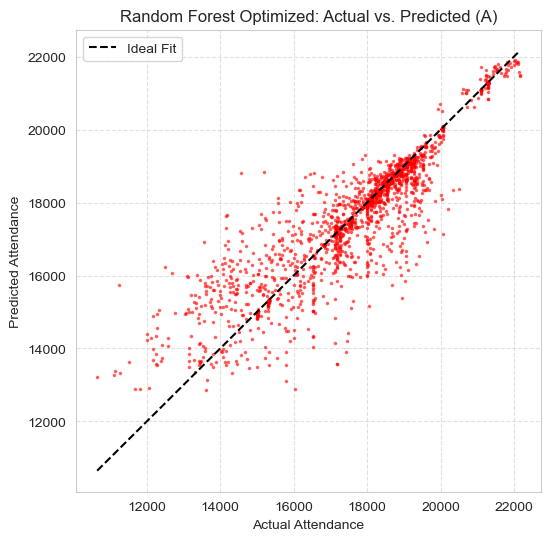

Results for Gradient Boosting - Dependent Variable: A
Train RMSE: 1006.2179, MAE: 703.9222, R²: 0.7238
Test  RMSE: 1043.6449, MAE: 722.2469, R²: 0.6991
--------------------------------------------------


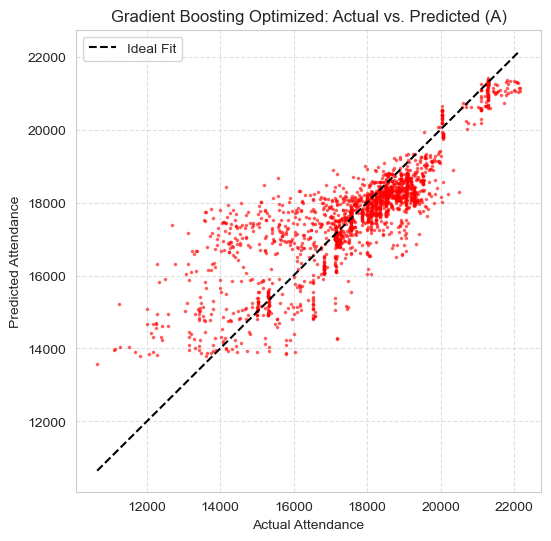

Results for Random Forest - Dependent Variable: LA
Train RMSE: 675.3557, MAE: 402.8330, R²: 0.8756
Test  RMSE: 870.2220, MAE: 510.8523, R²: 0.7908
--------------------------------------------------


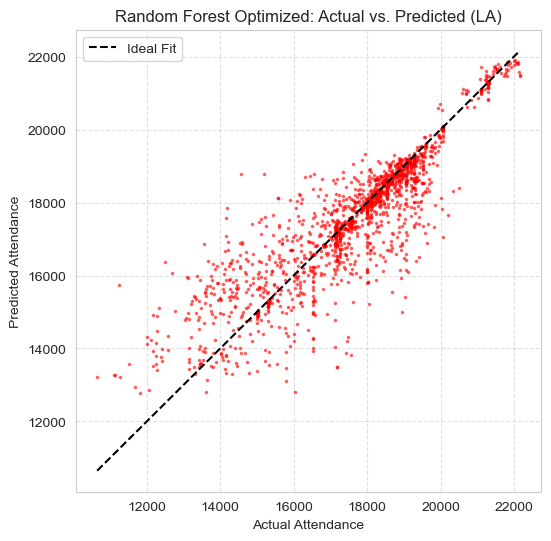

Results for Gradient Boosting - Dependent Variable: LA
Train RMSE: 902.7428, MAE: 629.9239, R²: 0.7777
Test  RMSE: 963.5762, MAE: 660.5837, R²: 0.7435
--------------------------------------------------


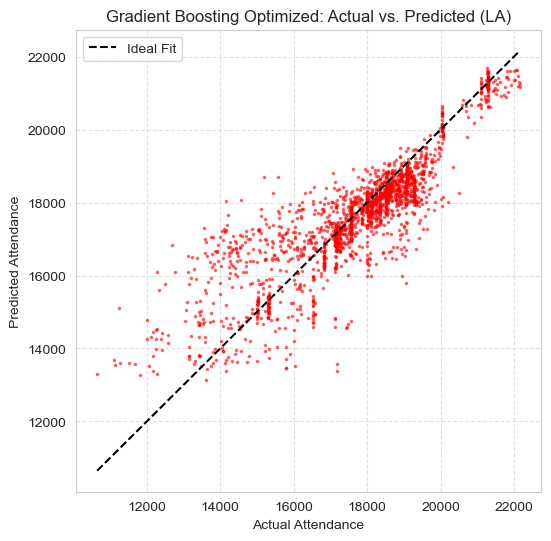

Results for Random Forest - Dependent Variable: PA
Train RMSE: 711.4185, MAE: 424.8872, R²: 0.8619
Test  RMSE: 879.8844, MAE: 516.1361, R²: 0.7861
--------------------------------------------------


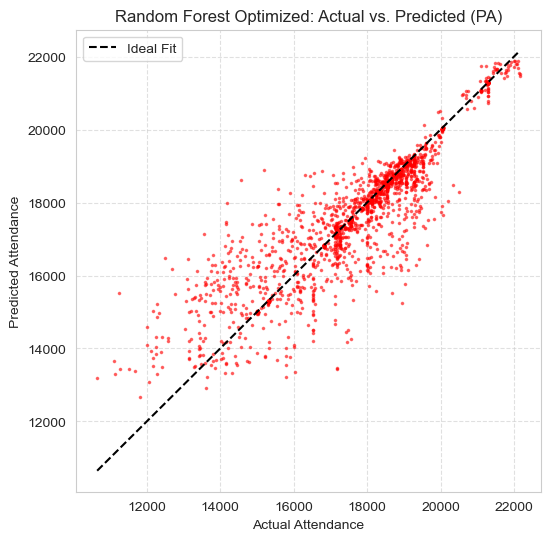

Results for Gradient Boosting - Dependent Variable: PA
Train RMSE: 739.9327, MAE: 483.6729, R²: 0.8506
Test  RMSE: 876.7248, MAE: 559.6143, R²: 0.7877
--------------------------------------------------


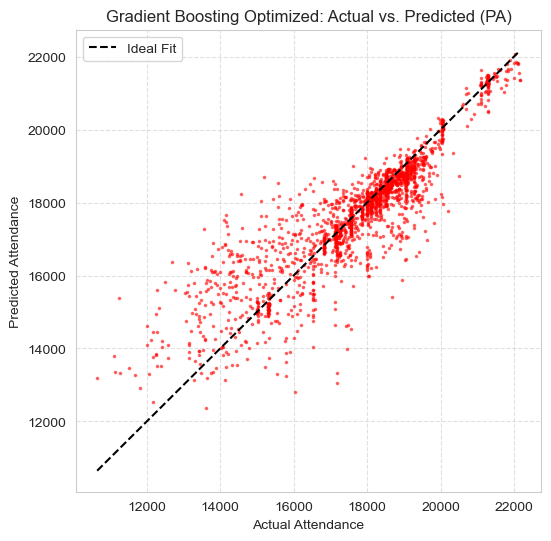

,Dep,Model,RMSE Train,MAE Train,R² Train,RMSE Test,MAE Test,R² Test
0,A,Random Forest,670.506081,399.440768,0.877343,864.387214,508.161909,0.793606
1,A,Gradient Boosting,1006.217904,703.922244,0.723769,1043.644916,722.246917,0.699125
2,LA,Random Forest,675.355700,402.832961,0.875562,870.222013,510.852295,0.790810
3,LA,Gradient Boosting,902.742771,629.923942,0.777661,963.576171,660.583732,0.743520
4,PA,Random Forest,711.418467,424.887207,0.861918,879.884397,516.136109,0.786139
5,PA,Gradient Boosting,739.932699,483.672864,0.850627,876.724807,559.614285,0.787672


In [23]:
# column names
columns = ["Dep", "Model", "RMSE Train", "MAE Train", "R² Train", "RMSE Test", "MAE Test", "R² Test"]

# initialize results list
results_list = []

# Loop through dependent variables and apply the best model for each
for dep in ['A', 'LA', 'PA']:
    # Prepare features and target variable
    if dep in ['A', 'PA']:
        X = df_att.drop(columns=['A', 'LA', 'PA', 'LCAP'])
    else:  # For 'LA'
        X = df_att.drop(columns=['A', 'LA', 'PA', 'CAP'])
    
    y = df_att[dep]
    
    # Split into train and test sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Select model type based on dependent variable
    rf_params = best_params[f"RandomForest_{dep}"]
    gb_params = best_params[f"GradientBoosting_{dep}"]

    # Train and evaluate both models
    for model_name, model_params, model_class in [
        ("Random Forest", rf_params, RandomForestRegressor),
        ("Gradient Boosting", gb_params, GradientBoostingRegressor)
    ]:
        # Instantiate the model with optimized hyperparameters
        model = model_class(random_state=rand_seed, **model_params)

        # Fit the model
        model.fit(X_train, y_train)
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        # **Adjust predictions based on dependent variable transformation**
        if dep == 'LA':  # Log Attendance was used → Apply exp()
            y_train_true, y_train_pred = np.exp(y_train), np.exp(y_train_pred)
            y_test_true, y_test_pred = np.exp(y_test), np.exp(y_test_pred)
        elif dep == 'PA':  # Percentage Attendance → Multiply by CAP
            y_train_true, y_train_pred = y_train * X_train['CAP'], y_train_pred * X_train['CAP']
            y_test_true, y_test_pred = y_test * X_test['CAP'], y_test_pred * X_test['CAP']
        else:  # 'A' (Raw Attendance) → No adjustment needed
            y_train_true, y_train_pred = y_train, y_train_pred
            y_test_true, y_test_pred = y_test, y_test_pred

        # Compute evaluation metrics
        rmse_train = np.sqrt(mean_squared_error(y_train_true, y_train_pred))
        mae_train = mean_absolute_error(y_train_true, y_train_pred)
        r2_train = r2_score(y_train_true, y_train_pred)

        rmse_test = np.sqrt(mean_squared_error(y_test_true, y_test_pred))
        mae_test = mean_absolute_error(y_test_true, y_test_pred)
        r2_test = r2_score(y_test_true, y_test_pred)

        # Store results in a list
        results_list.append({
            "Dep": dep,
            "Model": model_name,
            "RMSE Train": rmse_train,
            "MAE Train": mae_train,
            "R² Train": r2_train,
            "RMSE Test": rmse_test,
            "MAE Test": mae_test,
            "R² Test": r2_test
        })

        print(f"Results for {model_name} - Dependent Variable: {dep}")
        print(f"Train RMSE: {rmse_train:.4f}, MAE: {mae_train:.4f}, R²: {r2_train:.4f}")
        print(f"Test  RMSE: {rmse_test:.4f}, MAE: {mae_test:.4f}, R²: {r2_test:.4f}")
        print("-" * 50)

        # Scatter plot for actual vs predicted values
        fig, ax = plt.subplots(figsize=(6, 6))  # Define figure size
        ax.scatter(y_test_true, y_test_pred, alpha=0.5, color='red', marker='.', s=10)
        ax.plot([min(y_test_true), max(y_test_true)], [min(y_test_true), max(y_test_true)], 
                color='black', linestyle='--', label="Ideal Fit")  # Ideal fit line
        ax.set_title(f"{model_name} Optimized: Actual vs. Predicted ({dep})")
        ax.set_xlabel("Actual Attendance")
        ax.set_ylabel("Predicted Attendance")
        ax.grid(True, linestyle='--', alpha=0.6)
        ax.legend()
        
        plt.show()

# Convert list to DataFrame
df_results = pd.DataFrame(results_list)[columns]

# Display results table
df_results

In [22]:
# Try with not using the arizona coyotes --> inconsistent data and might be irrelevant
# remove coyotes (home team only)
df_att_no_coyotes_home = df_att.loc[df_att_all['H'] != 'Arizona Coyotes']
df_att_no_coyotes = df_att.loc[(df_att_all['H'] != 'Arizona Coyotes') & (df_att_all['V'] != 'Arizona Coyotes')]

# Dependent variable
deps = ['A', 'LA', 'PA']

print('No Arizona Coyotes Home Games')
for dep in deps:
    # Prepare features and target variable
    if dep == 'A' or dep == 'PA':
        X = df_att_no_coyotes_home.drop(columns=['A', 'LA', 'PA', 'LCAP'])
    else:
        X = df_att_no_coyotes_home.drop(columns=['A', 'LA', 'PA', 'CAP'])
    
    y = df_att_no_coyotes_home[dep]
    
    # Run all models with kfold CV
    cv_results = [kfold_cv(model, name, X, y, dep, model_params) for name, model in models.items()]
    
    # Convert results to a DataFrame
    df_cv_results = pd.DataFrame(cv_results)
    
    # display
    display(df_cv_results)

print('\nNo Arizona Coyotes Home and Visitor Games')
for dep in deps:
    # Prepare features and target variable
    if dep == 'A' or dep == 'PA':
        X = df_att_no_coyotes.drop(columns=['A', 'LA', 'PA', 'LCAP'])
    else:
        X = df_att_no_coyotes.drop(columns=['A', 'LA', 'PA', 'CAP'])
    
    y = df_att_no_coyotes[dep]
    
    # Run all models with kfold CV
    cv_results = [kfold_cv(model, name, X, y, dep, model_params) for name, model in models.items()]
    
    # Convert results to a DataFrame
    df_cv_results = pd.DataFrame(cv_results)
    
    # display
    display(df_cv_results)

No Arizona Coyotes Home Games


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.316e+09, tolerance: 2.722e+06
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.248e+09, tolerance: 2.756e+06
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.281e+09, toler

,RMSE Train,MAE Train,R² Train,RMSE Test,MAE Test,R² Test,Model
0,1245.809197,877.303567,0.553621,1390.381636,1007.545630,0.430473,OLS
1,1245.868244,877.472335,0.553578,1388.242042,1005.522538,0.432093,Lasso
2,1246.176115,877.246438,0.553363,1386.787876,1004.299687,0.433673,Ridge
3,1250.621402,878.938658,0.550149,1373.781953,997.959644,0.443540,ElasticNet
4,357.568548,152.664557,0.962966,1500.774635,933.251018,0.314491,Decision Tree
5,355.124189,200.323861,0.963688,1171.455682,782.276775,0.582655,Random Forest
6,882.345185,597.133104,0.775784,1201.322626,863.954718,0.568055,Gradient Boosting


,RMSE Train,MAE Train,R² Train,RMSE Test,MAE Test,R² Test,Model
0,1249.038006,897.234132,0.551290,1397.088028,1028.853500,0.424525,OLS
1,1251.813719,897.136815,0.549280,1378.116297,1014.679367,0.439500,Lasso
2,1249.055425,897.004578,0.551278,1392.602836,1025.046576,0.428499,Ridge
3,1254.608486,899.249763,0.547263,1379.603605,1018.350123,0.438587,ElasticNet
4,384.026371,169.969269,0.957514,1601.046394,1004.560614,0.207318,Decision Tree
5,355.253538,200.805141,0.963663,1199.852011,803.349091,0.556900,Random Forest
6,878.291013,605.300933,0.777944,1213.112407,880.351111,0.558505,Gradient Boosting


,RMSE Train,MAE Train,R² Train,RMSE Test,MAE Test,R² Test,Model
0,1246.041184,878.234289,0.553439,1385.256021,1003.599798,0.434350,OLS
1,1250.249904,878.484097,0.550406,1368.003165,990.649442,0.447653,Lasso
2,1246.140109,877.935179,0.553370,1381.168903,1000.027028,0.437937,Ridge
3,1251.814975,879.602001,0.549273,1368.206813,993.284596,0.447642,ElasticNet
4,442.236090,199.359447,0.942169,1657.627632,1054.011734,0.163487,Decision Tree
5,352.882144,199.022382,0.964151,1217.952286,822.187262,0.543011,Random Forest
6,886.155550,597.469901,0.773930,1189.338557,851.831508,0.576627,Gradient Boosting


No Arizona Coyotes Home and Visitor Games


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.149e+09, tolerance: 2.642e+06
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.055e+09, tolerance: 2.685e+06
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.065e+09, toler

,RMSE Train,MAE Train,R² Train,RMSE Test,MAE Test,R² Test,Model
0,1245.579825,876.449570,0.553993,1384.571619,1001.489522,0.435311,OLS
1,1245.639487,876.648981,0.553949,1382.474367,999.534322,0.436882,Lasso
2,1245.969890,876.381945,0.553718,1380.932899,998.204426,0.438550,Ridge
3,1250.369043,878.068169,0.550539,1368.173023,992.439979,0.448128,ElasticNet
4,354.427134,151.285418,0.963691,1548.611052,961.861685,0.266942,Decision Tree
5,355.719550,201.094232,0.963570,1175.777373,788.603149,0.577789,Random Forest
6,877.921481,592.687699,0.778170,1204.714420,862.741901,0.565973,Gradient Boosting


,RMSE Train,MAE Train,R² Train,RMSE Test,MAE Test,R² Test,Model
0,1248.816958,896.411948,0.551658,1391.293006,1022.778837,0.429289,OLS
1,1251.646074,896.425236,0.549611,1372.746424,1009.148142,0.443777,Lasso
2,1248.851711,896.174828,0.551635,1386.758178,1018.910435,0.433298,Ridge
3,1254.379546,898.409570,0.547640,1373.988909,1012.669063,0.443127,ElasticNet
4,376.878387,164.416125,0.959101,1550.665685,970.650820,0.250224,Decision Tree
5,354.907991,200.847653,0.963740,1187.880785,792.300844,0.563693,Random Forest
6,876.117208,602.000425,0.779095,1201.387239,867.177550,0.565812,Gradient Boosting


,RMSE Train,MAE Train,R² Train,RMSE Test,MAE Test,R² Test,Model
0,1245.797927,877.344773,0.553822,1379.592186,997.694080,0.438987,OLS
1,1250.030985,877.641149,0.550773,1362.886632,985.435536,0.451722,Lasso
2,1245.913582,877.055138,0.553742,1375.447409,993.996133,0.442620,Ridge
3,1251.563358,878.661127,0.549665,1362.736381,987.805268,0.452049,ElasticNet
4,398.153497,177.483091,0.953458,1568.596945,995.590950,0.255741,Decision Tree
5,351.976902,198.402674,0.964343,1203.592036,815.736200,0.556916,Random Forest
6,888.188636,598.606199,0.772969,1189.542179,854.639171,0.577155,Gradient Boosting
